# Predicting Water Quality from Satellite Imagery
### Cefni Reservoir, Anglesey, Wales, UK

**Author:** Hieda Silva &nbsp;|&nbsp; **Role focus:** Data Analyst / Data Scientist

This project estimates key water-quality indicators — **chlorophyll-a**, **turbidity**, and
**suspended solids** — directly from Landsat-8 satellite reflectance, removing the need for
constant manual field sampling at the reservoir.

It is a portfolio re-implementation of the remote-sensing + machine-learning methodology I
developed during my PhD research (University of Rome "La Sapienza"), rebuilt end-to-end with an
open-source Python stack (`pandas`, `scikit-learn`, `matplotlib`) so it is fully reproducible on
GitHub.

> **Note on the data:** the original study used proprietary water-quality measurements supplied
> by Welsh Water / Hamdden Ltd (2013–2017) and cannot be redistributed. The dataset used here is
> **synthetic**, generated to match the same variables, seasonal patterns, and error magnitudes
> reported in the original research, so the full pipeline can be published safely.

---
## Business problem

Water utilities need to monitor reservoir water quality (algal blooms, turbidity, sediment) to
protect drinking-water supply and comply with environmental regulation. Manual sampling is slow,
costly, and only covers a handful of points in time. **Can we estimate these parameters
continuously from free satellite imagery instead?**


## 1. Load data

In [ ]:
import pandas as pd

df = pd.read_csv("../data/cefni_reservoir_synthetic.csv", parse_dates=["date"])
df.head()

## 2. Signal pre-processing: Haar wavelet decomposition

Satellite reflectance signals are noisy. Following the same pre-processing idea used in the
original research, we decompose the green-band reflectance signal into an **approximation**
(low-frequency trend) and a **detail** (high-frequency noise) component using a Haar wavelet
transform, implemented from scratch with NumPy.

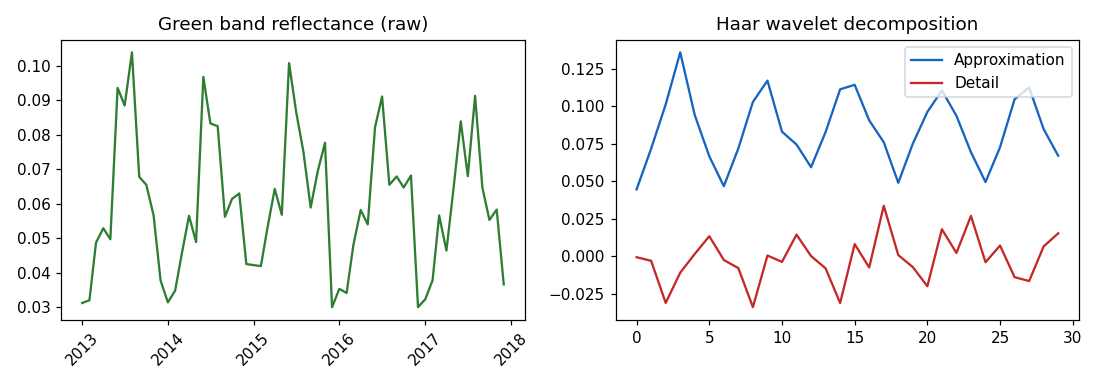

## 3. Exploratory analysis

Chlorophyll-a peaks in **summer**, consistent with algal bloom dynamics in shallow UK reservoirs.
Turbidity and suspended solids show a **winter/autumn** signature, linked to rainfall run-off and
resuspension of bottom sediment.

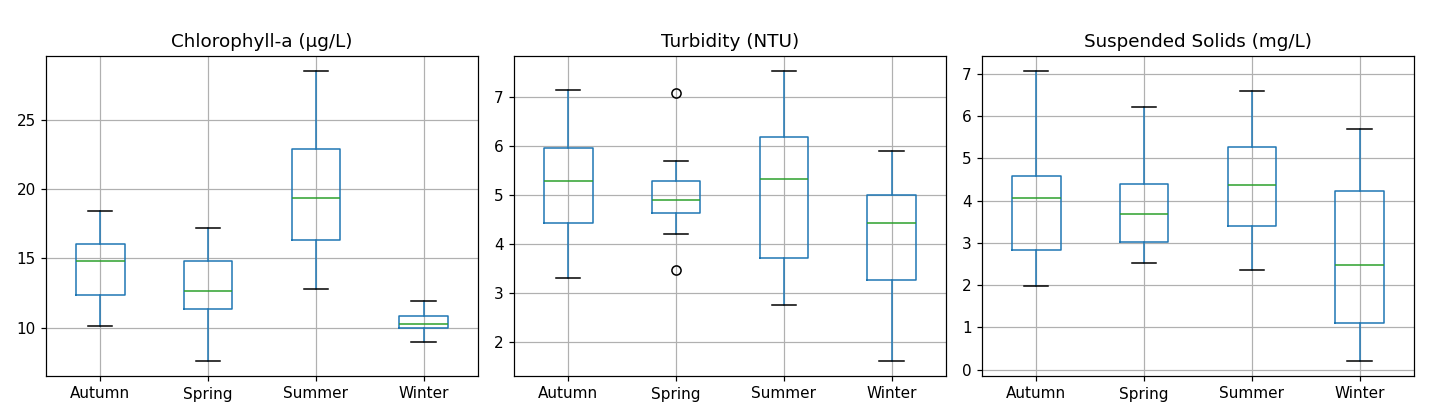

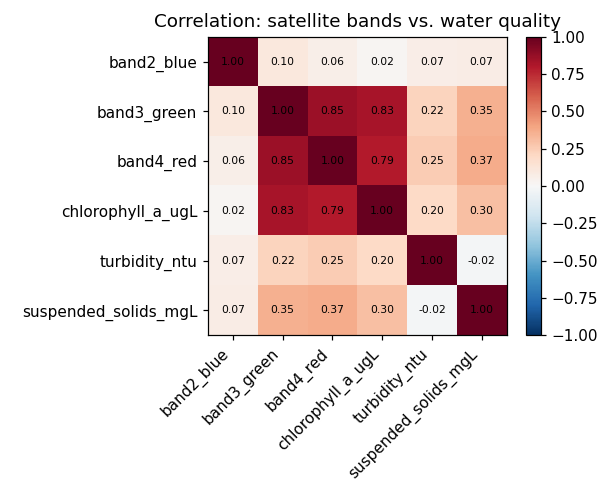

## 4. Dimensionality reduction (PCA)

The three Landsat-8 bands used (Blue, Green, Red) are correlated. PCA confirms most of the
spectral variance can be captured with 2 components — mirroring the factor-analysis step (KMO /
Bartlett test) used in the original thesis to justify band reduction before model training.

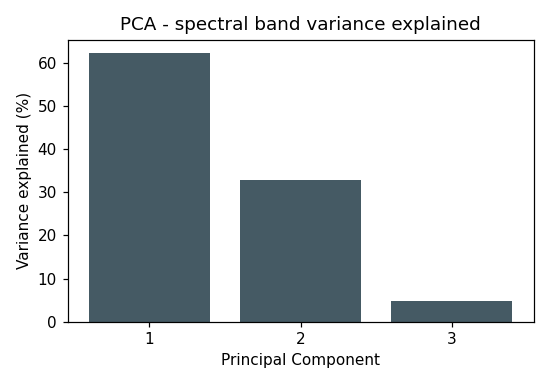

Variance explained by component: [62.3, 32.9, 4.8] %

## 5. Model comparison

The original research compared five estimation methods (Least Squares, RBF network, ANFIS,
ARIMA, and a Wavelet Neural Network). For this open-source rebuild, three scikit-learn
equivalents were trained **per season** and evaluated with the same metrics used in the thesis
(MSE and Relative Error):

| Original method | Portfolio equivalent |
|---|---|
| LSE (Least Squares Estimation) | `LinearRegression` |
| RBF Network | `SVR(kernel="rbf")` |
| WANN / ANFIS (Neural Network family) | `MLPRegressor` (ANN) |


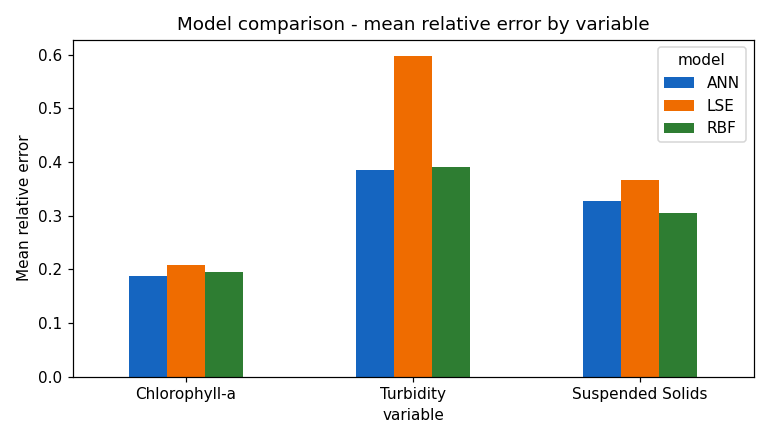

## 6. Results summary

- Dataset: 60 monthly samples (2013-01 to 2017-12)
- Overall mean relative error across all models/variables: **0.330**

- **chlorophyll_a_ugL** → best model: **ANN** (mean relative error: 0.188)
- **suspended_solids_mgL** → best model: **ANN** (mean relative error: 0.385)
- **turbidity_ntu** → best model: **RBF** (mean relative error: 0.305)

**Business takeaway:** a satellite-driven model can flag rising chlorophyll-a levels (early
warning for algal blooms) without waiting for the next scheduled field sample — a candidate
early-warning layer for reservoir management teams.


## 7. Next steps

- Validate against a longer, real observation record once available under a data-sharing agreement
- Add Sentinel-2 imagery (higher revisit frequency than Landsat-8)
- Package the best model behind a simple API / Power BI refreshable dataset for operational use
- See the companion **Power BI dashboard** in `/dashboard` for the stakeholder-facing view of these results
